In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad 

data_obs = np.loadtxt('lumSN2011kl.dat')
t_obs = data_obs[:,0]
L_obs = data_obs[:,1]
err_obs = data_obs[:,2]

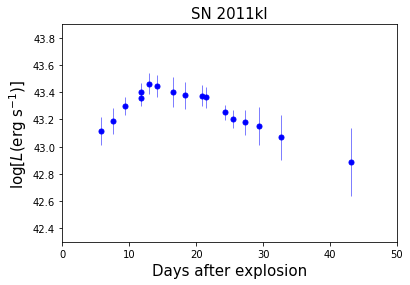

In [25]:
plt.errorbar(t_obs,L_obs,err_obs,fmt='o',ms=5,c='b',elinewidth=0.5)
plt.xlim(0,50)
plt.ylim(42.3,43.9)
plt.title('SN 2011kl',fontsize =15)
plt.xlabel('Days after explosion',fontsize =15)
plt.ylabel(r'$\log[L (\rm{erg \ s}^{-1})]$ ',fontsize =15)
plt.show()

In [26]:
# constants  unit cgs
c = 29979245800.0 # speed of light
M_sun = 1.9889999e33 # mass of sun
G =6.674*10**(-8)
pi =3.14159
day = 24.*3600  # day in unit second
epsilon_Ni = 3.9*10**10. # specific heating rate of Ni
epsilon_Co = 6.8*10**9. # specific heating rate of Co
tau_Ni = 8.8*day # half-life time for Ni-decay
tau_Co = 111.3*day # half-life time for Co-decay
hp = 6.626*10**(-27.0) ## the Planck constant
kb = 1.381*10**(-16.0) ## the Boltzmann constant
pc = 3.086*10**(18.0)
Mpc =10**(6.0)*pc
sigma_SB =5.670316237574177*10**(-5) # S-B constant
nm =1e-7 ## nm in unit of cm
lambda_g = 382.0*nm ## g-band wavelength
lambda_r = 495.0*nm ## r-band wavelength
nu_r = c/lambda_r ## frequency of r-band
nu_g = c/lambda_r ## frequency of g-band
km = 1e5 ## km in unit of cm

kappa=0.06; 
v = 20000.0*km


def model_optical(t,theta):
    M_ej,M_Ni=theta
    M_ej = M_ej*M_sun
    M_Ni =M_Ni*M_sun
    tau_d = (10.*kappa*M_ej/3./13.8/v/c)**0.5
    L_heat_Ni_const =M_Ni*(epsilon_Ni-epsilon_Co)
    epsilon_ratio = epsilon_Co/(epsilon_Ni-epsilon_Co)
    first_term = 2.0/tau_d**2.*np.exp(-t*t/tau_d/tau_d)
    L_heat_Ni_time = lambda x:  np.exp(-x/tau_Ni) + epsilon_ratio*np.exp(-x/tau_Co)    
    func_Ni = lambda x: x*np.exp(x**2/tau_d**2)*L_heat_Ni_time(x)
    I_Ni = quad(func_Ni,0,t,epsrel=1.49e-01)[0]
    L_Ni_out =I_Ni*first_term*L_heat_Ni_const
    
    return np.log10(L_Ni_out)

def model_optical_loop(x,theta):
    r = np.zeros(len(x))
    for i in range(len(x)):
        r[i] =np.array(model_optical(x[i],theta))
    return r

In [27]:
def lnprior(theta):
    M_ej,M_Ni=theta
    if (1.0 < M_ej < 10.0 and 0.1<M_Ni<3.0 ):
        return 0.0
    return -np.inf

def lnlike(theta):
    M_ej,M_Ni=theta
    chi2 = 0.0
    for i in range(t_obs.size):
        chi2 += (L_obs[i]- model_optical(t_obs[i]*day,theta))**2./err_obs[i]**2.0
    return -0.5*chi2

def lnprob(theta):
    lp = lnprior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike(theta)

In [28]:
theta0 =np.array([ 3.0, 0.9])
ndim = 2
nwalkers = 30
niter = 5000
pos = [theta0+1e-4*np.random.randn(ndim) for i in range(nwalkers)]

import emcee
import corner
sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob,threads=6)
sampler.run_mcmc(pos, niter, progress=True);
samples = sampler.chain[:,50:,:].reshape((-1,ndim))

100%|██████████████████████████████████████████████████████████████████████████████| 5000/5000 [03:45<00:00, 22.04it/s]


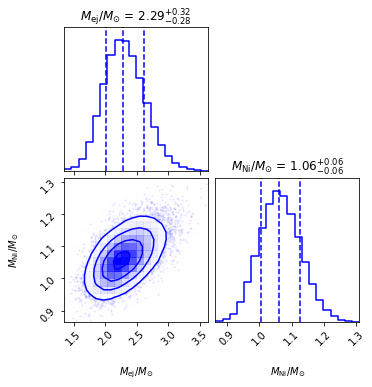

In [29]:
flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)
labels = [ r"$M_{\rm{ej}}/M_{\odot}$", r"$M_{\rm{Ni}}/M_{\odot}$"]
fig = corner.corner(flat_samples, labels=labels,color='b', smooth=True,smooth1d=True,show_titles=True,quantiles=[0.16,0.5,0.84]);
plt.savefig('optical-Ni_corner.pdf')

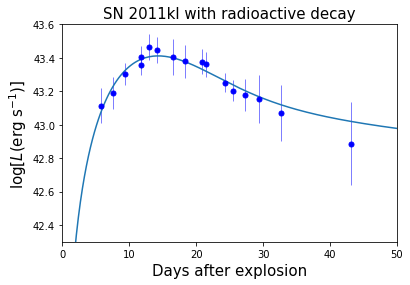

In [30]:
samples = sampler.flatchain
theta_max = samples[np.argmax(sampler.flatlnprobability)]
ts = np.linspace(0.01, 60, 200)*day
plt.errorbar(t_obs,L_obs,err_obs,fmt='o',ms=5,c='b',elinewidth=0.5)
plt.plot(ts/day, model_optical_loop(ts,theta_max))
plt.xlim(0,50)
plt.ylim(42.3,43.6)
plt.title('SN 2011kl with radioactive decay',fontsize =15)
plt.xlabel('Days after explosion',fontsize =15)
plt.ylabel(r'$\log[L (\rm{erg \ s}^{-1})]$ ',fontsize =15)
plt.show()

In [31]:
theta_max

array([2.24663161, 1.05450647])

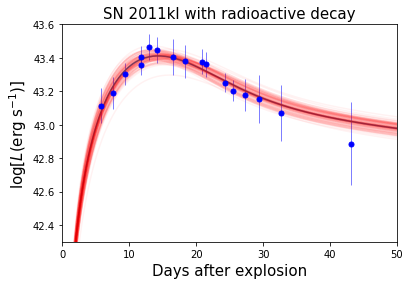

In [34]:
samples = sampler.flatchain
theta_max = samples[np.argmax(sampler.flatlnprobability)]
ts = np.linspace(0.01, 60, 200)*day
plt.errorbar(t_obs,L_obs,err_obs,fmt='o',ms=5,c='b',elinewidth=0.5)
plt.plot(ts/day, model_optical_loop(ts,theta_max))
for theta in samples[np.random.randint(len(samples),size=100)]:
    plt.plot(ts/day,model_optical_loop(ts,theta), color='r',alpha=0.05)
plt.xlim(0,50)
plt.ylim(42.3,43.6)
plt.title('SN 2011kl with radioactive decay',fontsize =15)
plt.xlabel('Days after explosion',fontsize =15)
plt.ylabel(r'$\log[L (\rm{erg \ s}^{-1})]$ ',fontsize =15)
plt.show()

In [35]:
new_samples = sampler.flatchain
ts = np.linspace(0.01, 60, 200)*day

def sample_walkers(nsamples, flattened_chain):
    models =[]
    draw = np.floor(np.random.uniform(0, len(flattened_chain),size=nsamples)).astype(int)
    thetas = flattened_chain[draw]
    for i in thetas:
        mod = model_optical_loop(ts,i)
        models.append(mod)
    spread = np.std(models,axis=0)
    med_model = np.median(models, axis=0)
    return med_model, spread

med_model, spread = sample_walkers(100,new_samples)
med_model2, spread2 = sample_walkers(100,new_samples)

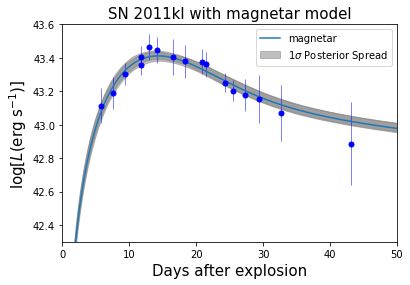

In [23]:
plt.errorbar(t_obs,L_obs,err_obs,fmt='o',ms=5,c='b',elinewidth=0.5)
plt.plot(ts/day, model_optical_loop(ts,theta_max),label='magnetar')
plt.xlim(0,50)
plt.ylim(42.3,43.6)
plt.title('SN 2011kl with magnetar model',fontsize =15)
plt.xlabel('Days after explosion',fontsize =15)
plt.ylabel(r'$\log[L (\rm{erg \ s}^{-1})]$ ',fontsize =15)
plt.fill_between(ts/day, med_model-spread, med_model+spread, color='grey', alpha=0.5)
plt.fill_between(ts/day, med_model2-spread2, med_model2+spread2, color='grey', alpha=0.5,label=r'$1\sigma$ Posterior Spread')
plt.legend()
plt.show()